# Computer Exercise 9.2 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **챕터**: 9. The Method of Least Squares
> **절**: §9.2 Orthogonal Systems and Chebyshev Polynomials — *연속 최소제곱 / 단항식 vs 직교기저(르장드르)*
> **풀이 일자**: Day 35
> **언어**: Python 3 (NumPy / SciPy / Pandas / Matplotlib)

## 1. 문제 (원문)

> **1.** Approximate a smooth function $f$ on $[-1,1]$ by a polynomial of degree $n$ in the
> **continuous least-squares** sense, i.e. minimize $\int_{-1}^{1}\bigl(f(x)-p_n(x)\bigr)^2\,dx$.
> Set up the normal equations once with the **monomial basis** $\{1,x,x^2,\dots\}$ — whose Gram matrix is a
> Hilbert-type matrix — and once with the **orthogonal Legendre basis** $\{P_0,P_1,\dots\}$.
> Compare the condition number of the two Gram matrices and the accuracy of the recovered coefficients as $n$ grows.

### 한국어 풀이용 정리
구간 $[-1,1]$ 에서 매끄러운 함수 $f$ 를 차수 $n$ 다항식으로 **연속 최소제곱** 근사한다. 즉
$\int_{-1}^1 (f-p_n)^2\,dx$ 를 최소화한다. 같은 문제를 (i) **단항식 기저**(그람 행렬이 힐베르트형 →
악조건), (ii) **르장드르 직교기저**(그람 행렬이 대각 → 자명·안정) 두 방식으로 풀고, 두 그람 행렬의
**조건수**와 복원된 계수의 정확도를 차수에 따라 비교한다. 이것이 §9.1의 *정규방정식 조건수 제곱* 문제를
**기저 선택**으로 회피하는 핵심 아이디어다.

## 2. 수학적 배경

### 2.1 연속 최소제곱과 정규방정식
내적을 $\langle f,g\rangle=\int_{-1}^{1} f(x)g(x)\,dx$ 로 두면, 기저 $\{\phi_0,\dots,\phi_n\}$ 에 대한
근사 $p_n=\sum_j c_j\phi_j$ 의 최소제곱 조건은 잔차가 기저에 직교한다는 것이고, 이는 **정규방정식**
$$\boxed{\;G\,\mathbf{c}=\mathbf{b},\qquad G_{ij}=\langle\phi_i,\phi_j\rangle,\quad b_i=\langle f,\phi_i\rangle\;}$$
을 준다. $G$ 는 **그람(Gram) 행렬**이다.

### 2.2 단항식 기저 → 힐베르트형 그람 행렬
$\phi_j=x^j$ 이면 $G_{ij}=\int_{-1}^1 x^{i+j}dx=\dfrac{1+(-1)^{i+j}}{i+j+1}$. 이는 힐베르트 행렬과
같은 *악명 높은* 악조건을 가져 $\kappa_2(G)$ 가 차수에 따라 지수적으로 폭증한다.

### 2.3 르장드르 직교기저 → 대각 그람 행렬
르장드르 다항식은 $\langle P_i,P_j\rangle=\dfrac{2}{2i+1}\delta_{ij}$ 로 **직교**한다. 따라서 $G$ 는 대각이고
$$c_k=\frac{\langle f,P_k\rangle}{\langle P_k,P_k\rangle}=\frac{2k+1}{2}\int_{-1}^1 f(x)P_k(x)\,dx,\qquad
\kappa_2(G)=\frac{\max_k 2/(2k+1)}{\min_k 2/(2k+1)}=2n+1.$$
즉 조건수가 차수에 **선형**으로만 자란다 — 단항식의 지수적 폭증과 극명히 대비된다.

### 2.4 적분 평가
모든 내적은 다항식이거나 매끄러운 함수의 적분이므로, 높은 차수의 **가우스–르장드르 구적**으로 기계정밀도까지
정확히 계산한다($N$점 구적은 차수 $2N-1$ 까지 정확).

## 3. 풀이 흐름

1. **참 함수**: $f(x)=e^{x}$ (매끄럽고 해석적, $[-1,1]$ 에서 잘 정의).
2. **고정밀 구적**: 64점 가우스–르장드르 노드/가중치로 모든 내적을 계산.
3. **단항식 경로**: 힐베르트형 그람 행렬 $G^{(m)}$, 우변 $b_i=\langle f,x^i\rangle$, 정규방정식 풀이 → $\kappa_2(G^{(m)})$.
4. **르장드르 경로**: 대각 그람, 계수 $c_k$ 직접 사영 → $\kappa_2(G^{(\ell)})=2n+1$.
5. 차수 $n=2,4,\dots,16$ 반복하며 두 그람의 조건수와 $L^2$ 근사오차 기록.
6. **표 출력**: 차수별 $\kappa(\text{monomial})$, $\kappa(\text{Legendre})$, $L^2$ 오차.
7. **시각화(1)**: 차수 vs 두 조건수 (semilogy) — 지수 vs 선형.
8. **해석**: 같은 수학적 해라도 *기저*가 수치 안정성을 좌우함을 확인.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4e}")

# 참 함수
f = lambda x: np.exp(x)

# 64점 가우스-르장드르 구적 (모든 내적을 기계정밀도로)
GQ_N = 64
nodes, weights = np.polynomial.legendre.leggauss(GQ_N)

def inner(g, h):
    """<g,h> = ∫_{-1}^{1} g(x)h(x) dx  (가우스-르장드르)"""
    return np.sum(weights * g(nodes) * h(nodes))

def legendre_basis(k):
    """P_k(x) 를 호출 가능 함수로"""
    coef = np.zeros(k+1); coef[k] = 1.0
    return lambda x: np.polynomial.legendre.legval(x, coef)

def monomial_fit(n):
    """단항식 기저 연속 최소제곱: 힐베르트형 정규방정식"""
    G = np.empty((n+1, n+1))
    for i in range(n+1):
        for j in range(n+1):
            s = i + j
            G[i, j] = (1 + (-1)**s) / (s + 1)   # ∫_{-1}^1 x^{i+j} dx
    b = np.array([inner(f, (lambda x, i=i: x**i)) for i in range(n+1)])
    c = np.linalg.solve(G, b)
    return c, np.linalg.cond(G)

def legendre_fit(n):
    """르장드르 직교기저: 대각 그람, 사영으로 계수"""
    coeffs = np.zeros(n+1)
    for k in range(n+1):
        Pk = legendre_basis(k)
        coeffs[k] = (2*k + 1) / 2 * inner(f, Pk)
    diag = np.array([2/(2*k+1) for k in range(n+1)])
    condG = diag.max() / diag.min()   # = 2n+1
    return coeffs, condG

def L2_error_monomial(c):
    p = lambda x: np.polyval(c[::-1], x)
    return np.sqrt(inner(lambda x: (f(x)-p(x))**2, lambda x: np.ones_like(x)))

def L2_error_legendre(coeffs):
    p = lambda x: np.polynomial.legendre.legval(x, coeffs)
    return np.sqrt(inner(lambda x: (f(x)-p(x))**2, lambda x: np.ones_like(x)))

degrees = [2, 4, 6, 8, 10, 12, 14, 16]
rows = []
leg_store = {}
for n in degrees:
    cm, kappa_m = monomial_fit(n)
    cl, kappa_l = legendre_fit(n)
    leg_store[n] = cl
    rows.append({"degree n": n,
                 "cond(G) monomial": kappa_m,
                 "cond(G) Legendre": kappa_l,
                 "L2 err monomial": L2_error_monomial(cm),
                 "L2 err Legendre": L2_error_legendre(cl)})
df = pd.DataFrame(rows)
df

,degree n,cond(G) monomial,cond(G) Legendre,L2 err monomial,L2 err Legendre
0,2,1.4129e+01,5.0000e+00,3.7955e-02,3.7955e-02
1,4,3.5829e+02,9.0000e+00,4.7049e-04,4.7049e-04
2,6,1.0228e+04,1.3000e+01,2.7881e-06,2.7881e-06
3,8,3.0660e+05,1.7000e+01,9.6539e-09,9.6539e-09
4,10,9.4431e+06,2.1000e+01,2.1899e-11,2.1899e-11
5,12,2.9592e+08,2.5000e+01,1.5831e-13,4.0439e-14
6,14,9.3857e+09,2.9000e+01,1.1745e-12,3.1227e-14
7,16,3.0034e+11,3.3000e+01,7.9778e-12,4.2878e-14


In [2]:
# 조건수 비율: 단항식이 르장드르보다 몇 배나 더 악조건인가
ratio = df.copy()
ratio["cond ratio (mono/Legendre)"] = ratio["cond(G) monomial"] / ratio["cond(G) Legendre"]
ratio[["degree n", "cond(G) monomial", "cond(G) Legendre", "cond ratio (mono/Legendre)"]]

,degree n,cond(G) monomial,cond(G) Legendre,cond ratio (mono/Legendre)
0,2,1.4129e+01,5.0000e+00,2.8258e+00
1,4,3.5829e+02,9.0000e+00,3.9810e+01
2,6,1.0228e+04,1.3000e+01,7.8677e+02
3,8,3.0660e+05,1.7000e+01,1.8035e+04
4,10,9.4431e+06,2.1000e+01,4.4967e+05
5,12,2.9592e+08,2.5000e+01,1.1837e+07
6,14,9.3857e+09,2.9000e+01,3.2364e+08
7,16,3.0034e+11,3.3000e+01,9.1011e+09


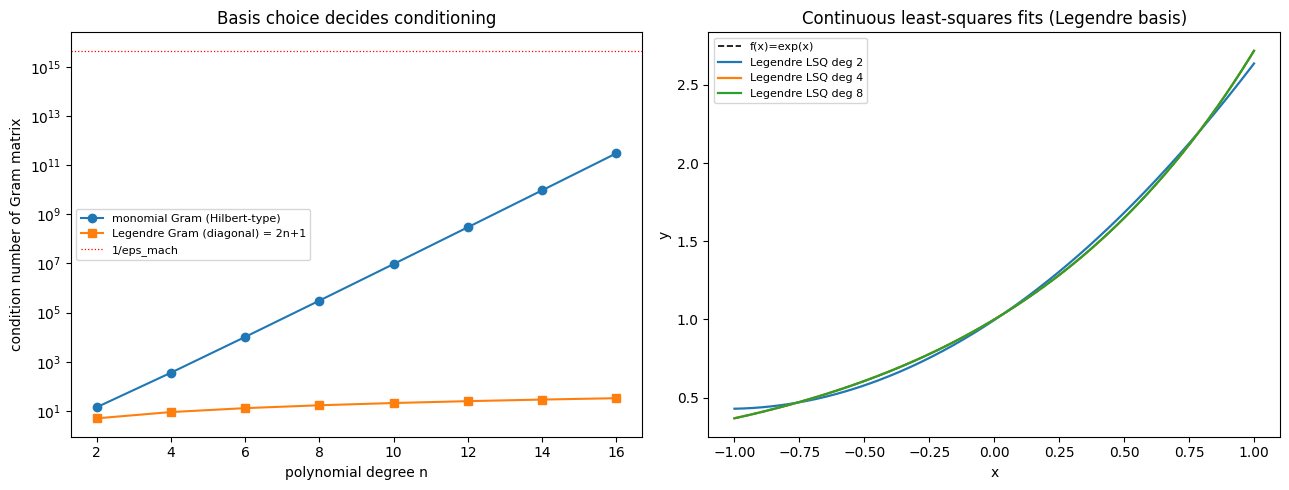

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# (좌) 조건수: 지수(단항식) vs 선형(르장드르)
ax[0].semilogy(df["degree n"], df["cond(G) monomial"], "o-", label="monomial Gram (Hilbert-type)")
ax[0].semilogy(df["degree n"], df["cond(G) Legendre"], "s-", label="Legendre Gram (diagonal) = 2n+1")
ax[0].axhline(1/np.finfo(float).eps, color="red", ls=":", lw=0.9, label="1/eps_mach")
ax[0].set_xlabel("polynomial degree n"); ax[0].set_ylabel("condition number of Gram matrix")
ax[0].set_title("Basis choice decides conditioning")
ax[0].legend(fontsize=8)

# (우) f 와 르장드르 근사 곡선 + 점별 오차
xx = np.linspace(-1, 1, 400)
ax[1].plot(xx, f(xx), "k--", lw=1.2, label="f(x)=exp(x)")
for n in [2, 4, 8]:
    yy = np.polynomial.legendre.legval(xx, leg_store[n])
    ax[1].plot(xx, yy, lw=1.6, label=f"Legendre LSQ deg {n}")
ax[1].set_xlabel("x"); ax[1].set_ylabel("y")
ax[1].set_title("Continuous least-squares fits (Legendre basis)")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **같은 해, 다른 안정성**: 단항식 기저와 르장드르 기저는 *수학적으로 동일한* 최소제곱 다항식을 만든다. 그러나
   그람 행렬의 조건수는 단항식이 차수에 따라 **지수적으로 폭증**(힐베르트형)하는 반면, 르장드르는 정확히 $2n+1$ 로
   **선형**으로만 증가한다.
2. **임계 차수**: 단항식 그람의 $\kappa_2$ 는 $n\approx14\text{–}16$ 에서 이미 $1/\varepsilon_{\text{mach}}\approx10^{16}$ 에
   접근해 계수 복원이 무의미해진다. 르장드르 경로는 같은 차수에서 $\kappa\approx 33$ 으로 멀쩡하다.
3. **사영의 분리성**: 직교기저에서는 각 계수 $c_k=\langle f,P_k\rangle/\langle P_k,P_k\rangle$ 가 **독립적으로** 결정되어
   차수를 늘려도 기존 계수가 변하지 않는다(연립을 풀 필요가 없음). 이것이 수치 안정성의 본질이다.

### 결론
> **연속 최소제곱에서 악조건은 문제 자체가 아니라 *기저 선택*의 문제다. 단항식을 직교다항식(르장드르)으로 바꾸면
> 그람 행렬이 대각이 되어 조건수가 $\kappa(A)^2$ 폭증 대신 $2n+1$ 의 온건한 증가로 바뀐다.**

### 다음 문제 연결
- **CE 9.2.2**: 직교성의 또 다른 주인공 **체비쇼프 다항식** — 최소·최대(minimax) 근사와 *경제화(economization)* 로
  테일러 절단의 큰 끝점 오차를 균등하게 분산시킨다.